In [1]:
import importlib
import cosinorage as csa

import utils
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data, plot_cohort_feature_comparison

### Computation of wear periods

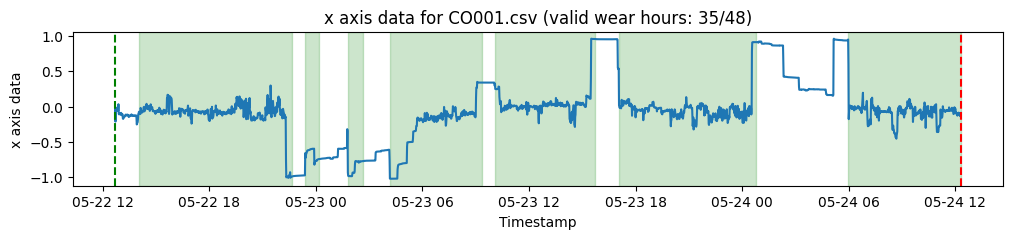

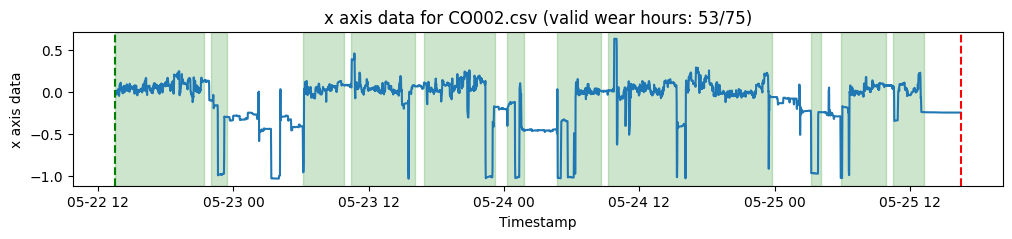

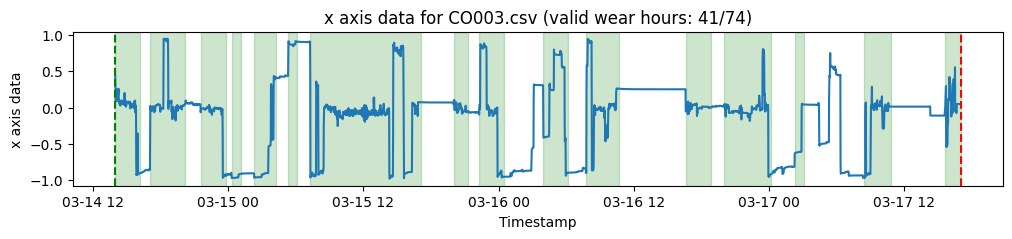

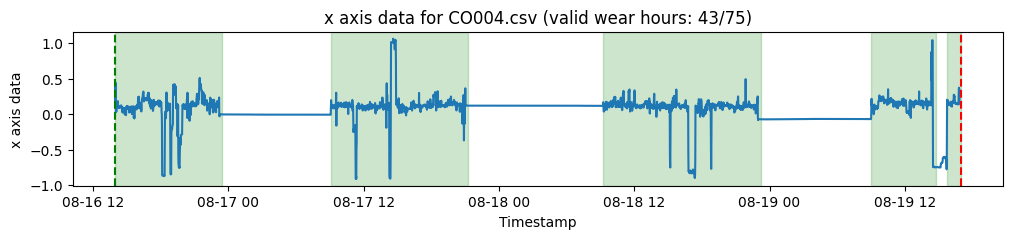

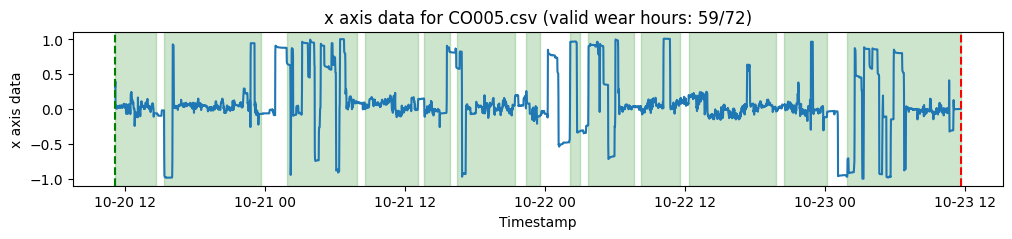

In [2]:
recompute_wear_periods()
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=5, axis='x')

### Modification of values during during non-wear periods

During day time the mean of the timeseries is taken and during night time the values are set to 0.


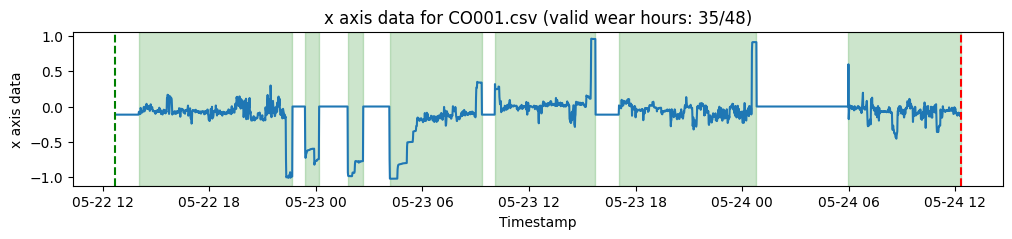

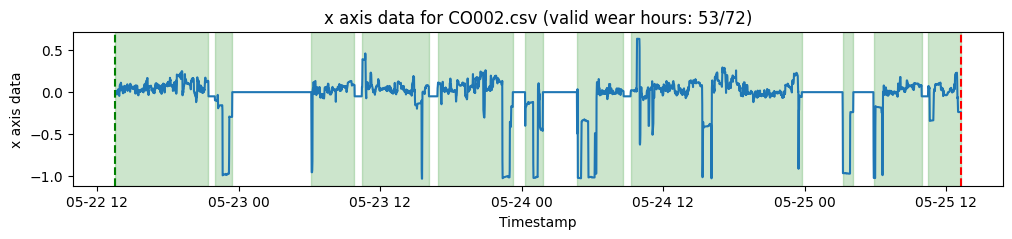

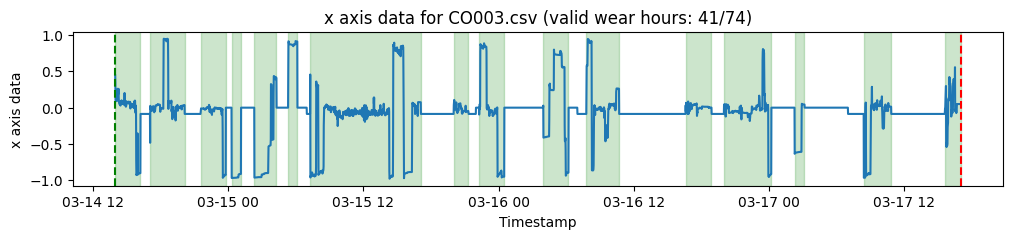

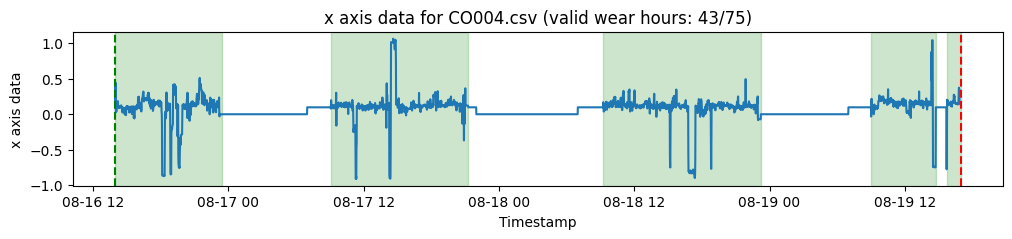

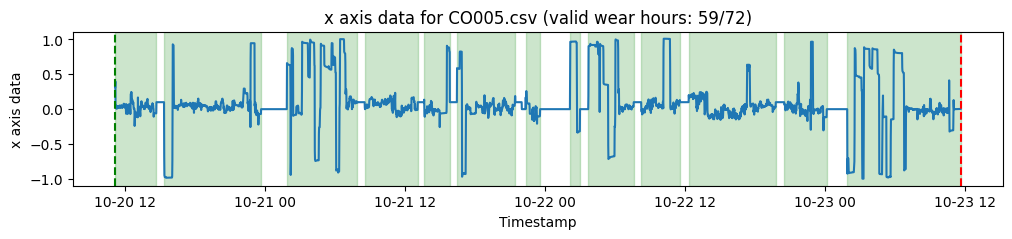

In [3]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00")
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=5, axis='x')

### Average circadian rhythm per cohort 

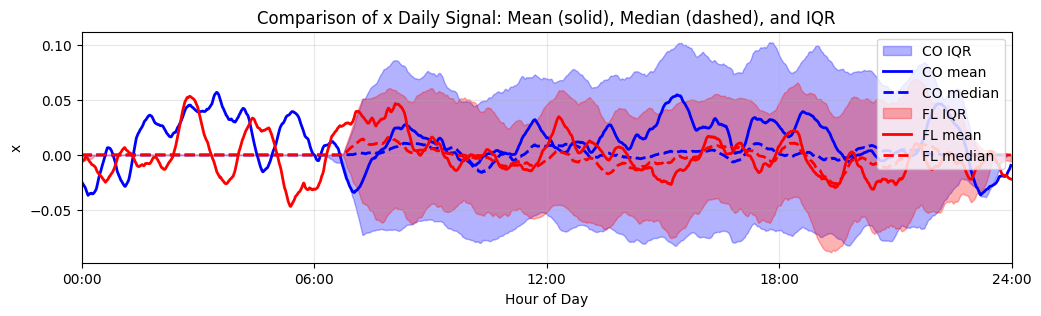

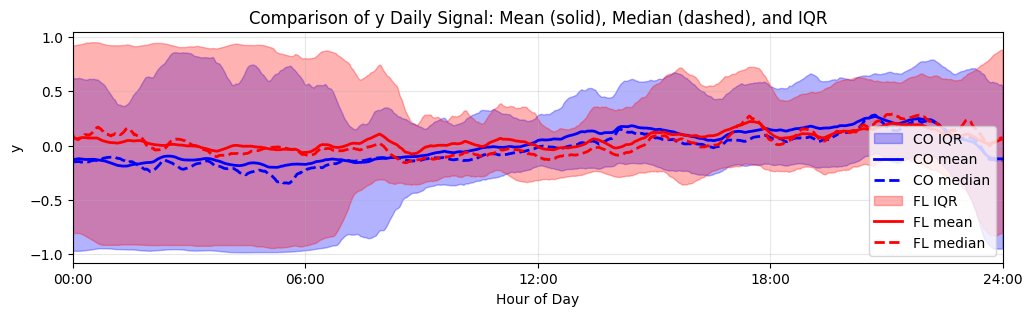

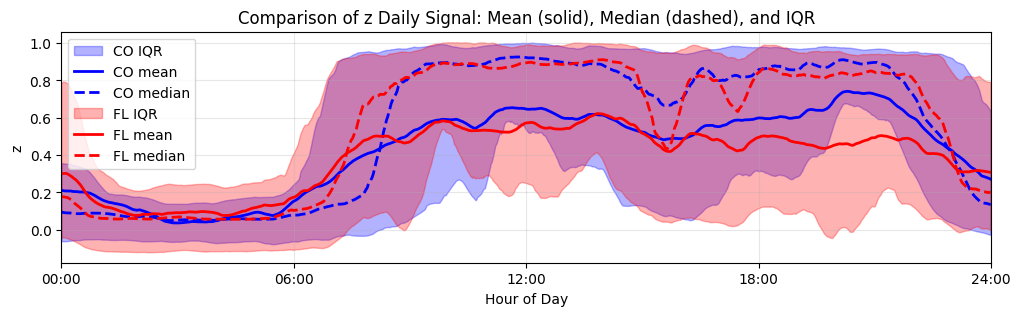

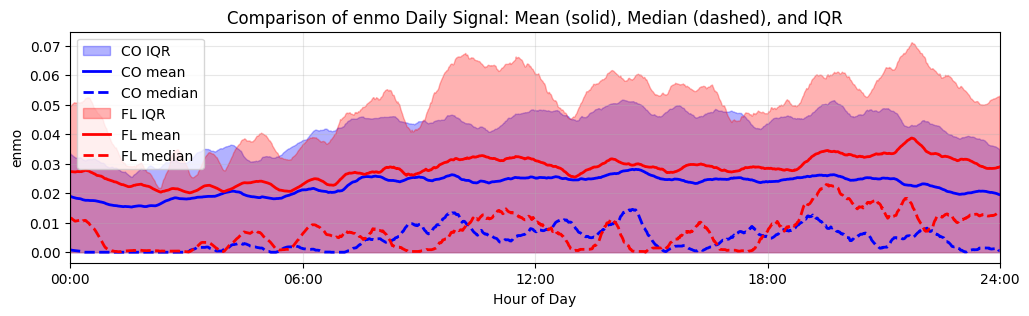

In [4]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30, plot_minmax=False)

### CosinorAge analysis per cohort

In [5]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None)

features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

Error processing CO024.csv: Less than 1 day found
Error processing FL009.csv: Less than 1 day found


In [6]:
co_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,33,21.149591,15.322307,0.890176,52.786119,18.520061,7.454066,30.354279,22.900213,0.890176,0.556062
1,cosinor_amplitude,33,13.918477,10.372564,0.637734,39.680426,12.570703,4.558700,17.671291,13.112591,0.637734,0.812819
2,cosinor_acrophase,33,-3.063444,1.710888,-5.888238,-0.178364,-3.568424,-4.219508,-1.339595,2.879914,-5.888238,0.133104
3,cosinor_acrophase_time,33,702.089714,392.106537,40.877990,1349.484643,817.822428,307.012450,967.040103,660.027653,40.877990,-0.133104
4,nonparam_IS,33,0.647500,0.258997,0.209507,1.000000,0.696560,0.425266,0.865070,0.439803,1.000000,-0.142131
5,nonparam_IV,33,0.712327,0.404047,0.147677,1.764827,0.638272,0.411339,0.973655,0.562316,0.147677,0.950847
6,nonparam_M10,33,33.931418,22.264462,1.589911,78.685787,34.013045,17.110427,45.722024,28.611598,1.589911,0.361614
7,nonparam_L5,33,3.451006,5.460756,0.000000,20.140735,0.049367,0.000000,5.371754,5.371754,0.000000,1.718909
8,nonparam_RA,33,0.883366,0.157428,0.514552,1.000000,0.995329,0.762435,1.000000,0.237565,1.000000,-1.073425
9,physical_activity_sedentary,33,744.636364,354.191253,116.500000,1380.500000,750.000000,479.500000,1023.000000,543.500000,116.500000,0.094340


In [7]:
fl_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,19,29.433992,21.093513,0.271353,66.063597,29.294563,11.502562,50.221744,38.719183,0.271353,0.142508
1,cosinor_amplitude,19,20.308612,19.108792,0.481818,79.177860,14.344707,4.819669,28.160185,23.340516,0.481818,1.613568
2,cosinor_acrophase,19,-3.564005,1.867620,-6.264906,-0.487066,-4.183278,-4.754948,-2.023210,2.731738,-6.264906,0.640279
3,cosinor_acrophase_time,19,816.809870,428.026880,111.627330,1435.810800,958.736686,463.685582,1089.753779,626.068197,111.627330,-0.640279
4,nonparam_IS,19,0.672460,0.251720,0.263043,1.000000,0.707921,0.420373,0.897512,0.477139,1.000000,-0.146141
5,nonparam_IV,19,0.698114,0.412195,0.143992,1.615993,0.680341,0.313576,1.021737,0.708161,0.143992,0.459755
6,nonparam_M10,19,43.352075,30.211137,0.651246,89.119899,34.537045,20.432172,76.227949,55.795777,0.651246,0.131474
7,nonparam_L5,19,6.730473,10.151257,0.000000,39.375710,1.903126,0.000000,9.466920,9.466920,0.000000,2.058727
8,nonparam_RA,19,0.802912,0.238535,0.214535,1.000000,0.949827,0.613143,1.000000,0.386857,1.000000,-1.034210
9,physical_activity_sedentary,19,650.526316,381.990062,133.000000,1382.000000,517.000000,356.250000,869.500000,513.250000,133.000000,0.764012


In [8]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.759551,-0.163857,0.163857,0.232177,-0.418346,0.970185,0.618723,-0.499552,-0.843298,...,0.008385,0.844023,-0.791987,0.256216,-0.791986,-0.214649,0.208547,0.229094,-0.556031,-0.730160
cosinor_amplitude,0.759551,1.000000,0.106589,-0.106589,0.334502,-0.583961,0.858234,0.162351,-0.003520,-0.465346,...,0.063812,0.465448,-0.403408,0.001134,-0.403406,-0.153998,0.139881,0.114544,-0.734838,-0.784642
cosinor_acrophase,-0.163857,0.106589,1.000000,-1.000000,0.195072,-0.260408,-0.114985,-0.144407,0.045241,0.143282,...,0.307166,-0.145500,0.306829,-0.135675,0.306829,0.321289,-0.025303,0.410761,-0.104601,-0.104412
cosinor_acrophase_time,0.163857,-0.106589,-1.000000,1.000000,-0.195072,0.260408,0.114985,0.144407,-0.045241,-0.143282,...,-0.307166,0.145500,-0.306829,0.135675,-0.306829,-0.321289,0.025303,-0.410761,0.104601,0.104412
nonparam_IS,0.232177,0.334502,0.195072,-0.195072,1.000000,0.018466,0.178075,0.033159,0.102075,-0.175454,...,-0.331909,0.177351,-0.187591,-0.093464,-0.187588,-0.429272,-0.073243,0.682199,-0.031283,-0.150730
nonparam_IV,-0.418346,-0.583961,-0.260408,0.260408,0.018466,1.000000,-0.514538,-0.087523,0.046025,0.453287,...,-0.218203,-0.452412,0.396021,-0.083217,0.396019,0.014074,-0.391120,0.045523,0.665812,0.707337
nonparam_M10,0.970185,0.858234,-0.114985,0.114985,0.178075,-0.514538,1.000000,0.504370,-0.369785,-0.765113,...,0.038467,0.765626,-0.713480,0.226578,-0.713480,-0.181266,0.216660,0.133565,-0.679597,-0.815175
nonparam_L5,0.618723,0.162351,-0.144407,0.144407,0.033159,-0.087523,0.504370,1.000000,-0.927259,-0.742833,...,0.048842,0.743150,-0.646058,0.332496,-0.646058,-0.120425,0.056541,0.277863,-0.083971,-0.309738
nonparam_RA,-0.499552,-0.003520,0.045241,-0.045241,0.102075,0.046025,-0.369785,-0.927259,1.000000,0.747407,...,-0.231302,-0.746571,0.642719,-0.456519,0.642720,-0.079218,-0.054697,-0.264222,-0.025282,0.237244
physical_activity_sedentary,-0.843298,-0.465346,0.143282,-0.143282,-0.175454,0.453287,-0.765113,-0.742833,0.747407,1.000000,...,-0.144592,-0.999984,0.953794,-0.481868,0.953794,0.133318,-0.260727,-0.300253,0.391859,0.675324


In [9]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.750381,0.147669,-0.147669,0.397566,-0.027786,0.981043,0.692161,-0.456396,-0.710341,...,-0.132688,0.715619,-0.756740,0.421214,-0.756741,-0.225015,-0.198028,0.563323,-0.745342,-0.934364
cosinor_amplitude,0.750381,1.000000,0.115414,-0.115414,0.549953,-0.436694,0.855668,0.102276,0.088719,-0.463522,...,0.111986,0.463898,-0.539462,0.204268,-0.539463,-0.155044,-0.012749,0.319744,-0.534735,-0.762407
cosinor_acrophase,0.147669,0.115414,1.000000,-1.000000,-0.093301,-0.407241,0.181609,0.039774,-0.284573,-0.447852,...,0.252997,0.445587,-0.436429,0.553920,-0.436426,0.493493,0.003489,0.185536,-0.070535,-0.352053
cosinor_acrophase_time,-0.147669,-0.115414,-1.000000,1.000000,0.093301,0.407241,-0.181609,-0.039774,0.284573,0.447852,...,-0.252997,-0.445587,0.436429,-0.553920,0.436426,-0.493493,-0.003489,-0.185536,0.070535,0.352053
nonparam_IS,0.397566,0.549953,-0.093301,0.093301,1.000000,-0.003597,0.472256,0.100108,0.078931,-0.315569,...,0.492257,0.309029,-0.155764,0.487788,-0.155762,-0.011026,-0.383841,0.403221,-0.506696,-0.379806
nonparam_IV,-0.027786,-0.436694,-0.407241,0.407241,-0.003597,1.000000,-0.136059,0.396704,-0.236860,0.250064,...,-0.459101,-0.243803,0.225193,-0.180342,0.225192,-0.371222,0.126804,-0.091354,0.045007,0.184949
nonparam_M10,0.981043,0.855668,0.181609,-0.181609,0.472256,-0.136059,1.000000,0.571187,-0.335361,-0.690998,...,-0.063584,0.695098,-0.738179,0.405915,-0.738180,-0.205483,-0.152823,0.526897,-0.721936,-0.938351
nonparam_L5,0.692161,0.102276,0.039774,-0.039774,0.100108,0.396704,0.571187,1.000000,-0.841182,-0.598269,...,-0.245300,0.604723,-0.554866,0.488336,-0.554866,-0.057391,-0.330986,0.554345,-0.512845,-0.556775
nonparam_RA,-0.456396,0.088719,-0.284573,0.284573,0.078931,-0.236860,-0.335361,-0.841182,1.000000,0.690083,...,0.082097,-0.694227,0.613595,-0.529240,0.613593,-0.210673,0.236560,-0.630384,0.374593,0.358662
physical_activity_sedentary,-0.710341,-0.463522,-0.447852,0.447852,-0.315569,0.250064,-0.690998,-0.598269,0.690083,1.000000,...,-0.272318,-0.999880,0.898911,-0.609173,0.898910,-0.088097,0.242441,-0.780826,0.657769,0.726531


### Feature distribution per cohort

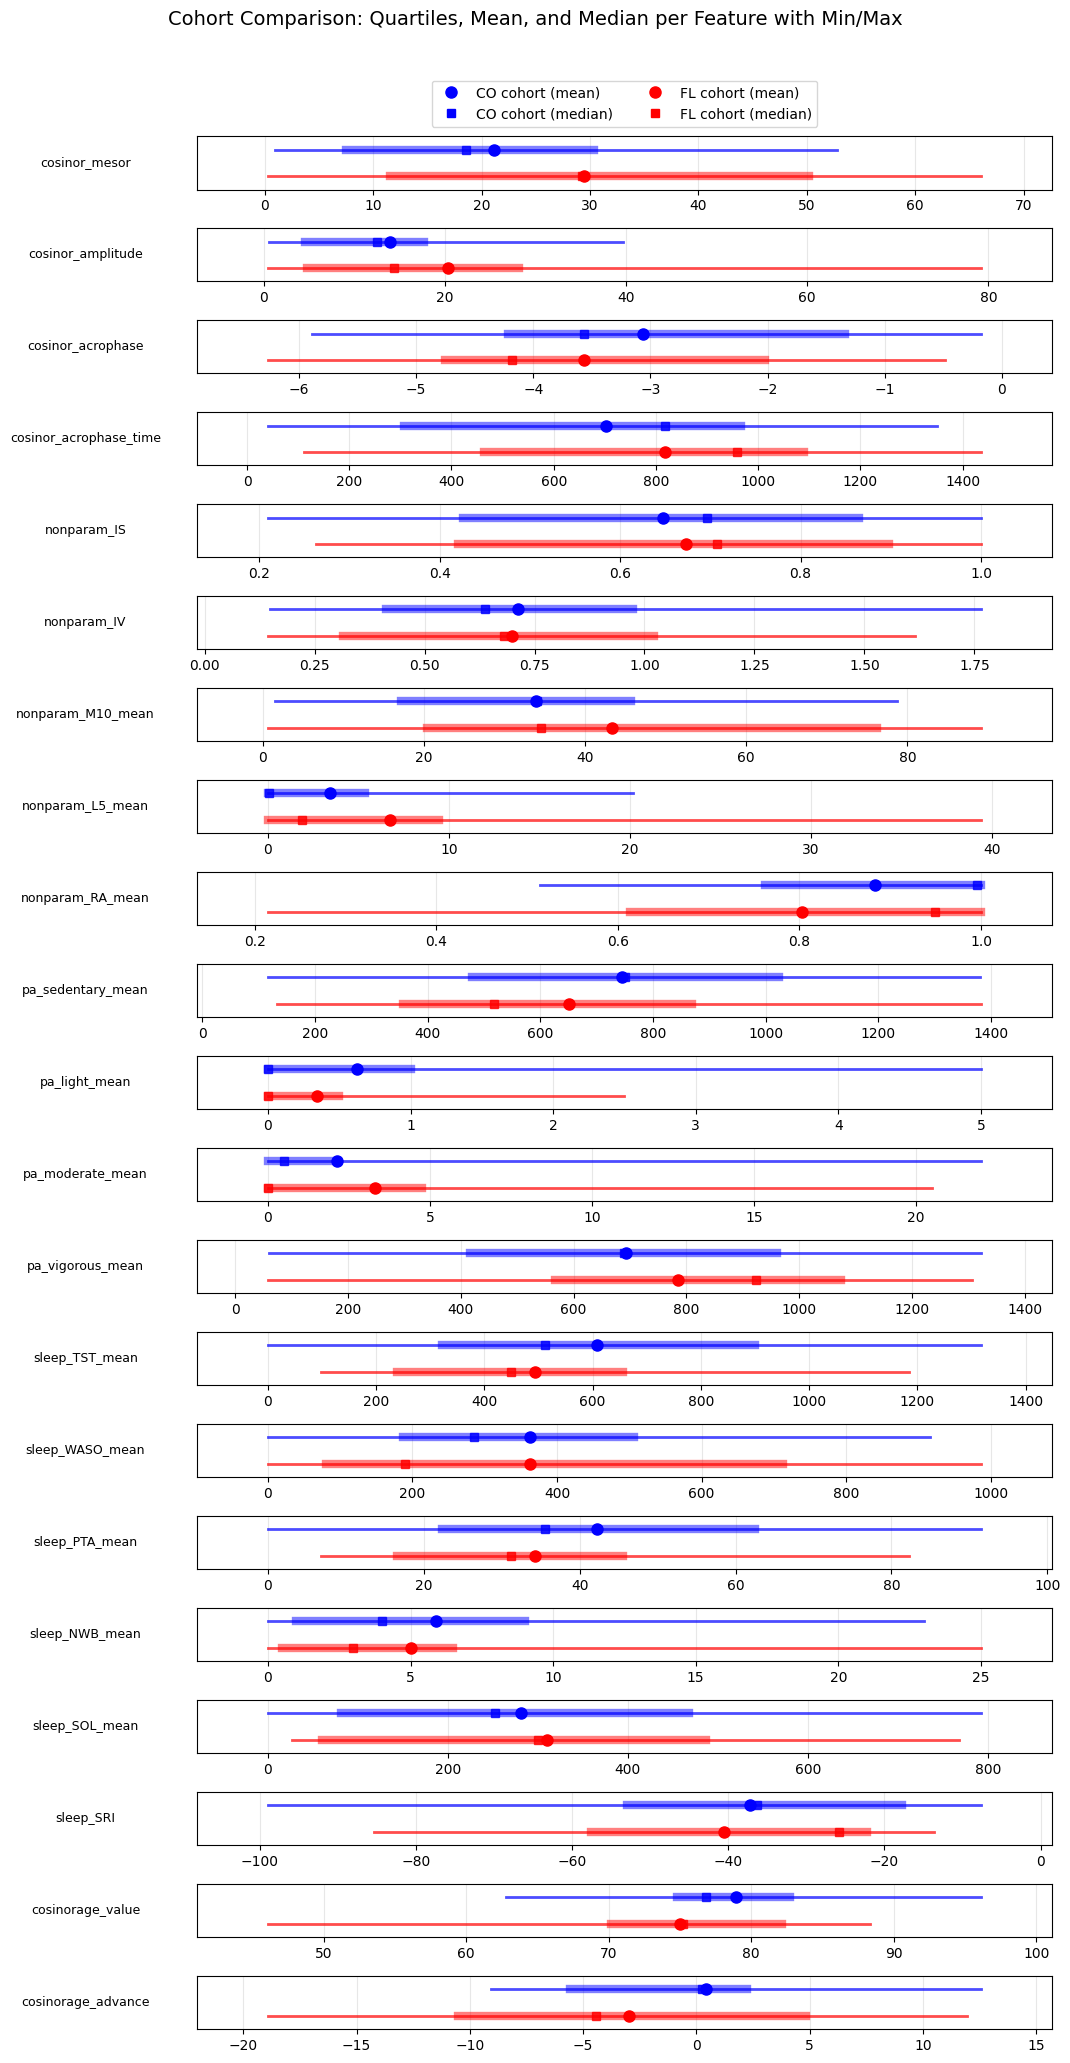

In [10]:
plot_cohort_feature_comparison(co_features, fl_features, title=None, plot_minmax=True)